In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing")
import importlib
import functions.mdata_utils as mdata_utils
import functions.TCR_embedings as TCR_embedings

In [4]:
# importlib.reload(TCR_embedings)

In [5]:
# data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external"

type_sets = {
    "CD4"     : ['Cd4'],
    "CD8"     : ['Cd8a', 'Cd8b1','Nkg7'],
}

CD4_cell_types = {
    "Treg"    : ['Foxp3', 'Il2ra', 'Ctla4', 'Ikzf2'],
    "Th1"     : ['Tbx21', 'Stat1', 'Stat4', 'Ifng', 'Tnf', 'Il2', 'Cxcr3', 'Ccr5', 'Il12rb1', 'Il12rb2', 'Il18r1'],
    "Th2"     : ['Gata3', 'Stat6', 'Il4', 'Il5', 'Il13', 'Ccr4', 'Ccr8', 'Il1rl1', 'Ptgdr2', 'Areg'],
    "Th17"    : ['Rorc', 'Rora', 'Stat3', 'Batf', 'Il17a', 'Il17f', 'Il22', 'Il21', 'Ccr6', 'Il23r'],
}

common_states = {
    "Naive"         : ['Ccr7', 'Sell', 'Tcf7', 'Lef1', 'Il7r'],   # both CD4 and CD8 naive
    "Cytotoxic"     : ['Gzmb', 'Gzma', 'Gzmk', 'Prf1', 'Nkg7'],  # Tem_CD8, SLEC, Tex_term, Th1-cytotoxic
    "Exhaustion_core": ['Pdcd1', 'Tox', 'Lag3', 'Tigit', 'Havcr2'], # shared across Tpex, Tex_int, Tex_term
    "Tcf7_stem"     : ['Tcf7', 'Bcl2', 'Id3', 'Bach2'],           # Tpex, MPEC, Naive
    "Proliferating" : ['Mki67', 'Top2a', 'Tyms', 'Cdk1'],         # any cycling T cell
    "IFN_stim"      : ['Isg15', 'Ifit1', 'Ifit3', 'Mx1', 'Oas1a', 'Gbp2'],
    "Early_activ"   : ['Cd69','Cd28', 'Icos', 'Nr4a1', 'Nr4a2', 'Fos', 'Jun'],
    "Memory_core"   : ['Il7r', 'Bcl2', 'S100a4', 'Ccl5'],         # Tcm, Tem, MPEC
    "Effector_core" : ['Cx3cr1', 'S1pr1', 'Zeb2', 'Tbx21'],       # SLEC, Tem_CD8, Tex_KLR
}


In [6]:
all_important_genes = []
for gene_list in type_sets.values():
    all_important_genes.extend(gene_list)
for gene_list in CD4_cell_types.values():
    all_important_genes.extend(gene_list)
for gene_list in common_states.values():
    all_important_genes.extend(gene_list)


In [23]:
n_top_genes = 2000
data_path = "E:\Biology\scRNA\Mouse test EAE\External\GEX and TCR\GSE156718 CD4"
h5mu_file = data_path + '\GSE156718.h5mu'

mdata = mu.read(h5mu_file)
mdata

MuData object with n_obs × n_vars = 11856 × 31053
  obs:	'batch'
  2 modalities
    airr:	11856 x 0
      obsm:	'airr'
    gex:	11856 x 31053
      obs:	'TCR_clonotype_frequency', 'tissue'

In [ ]:
adata.var[adata.var['feature_types'] == 'Antibody Capture']

Index(['Xkr4', 'Gm1992', 'Gm37381', 'Rp1', 'Sox17', 'Gm37323', 'Mrpl15',
       'Lypla1', 'Gm37988', 'Tcea1',
       ...
       'AC125149.1', 'AC125149.2', 'AC125149.4', 'AC234645.1', 'AC168977.2',
       'AC168977.1', 'AC149090.1', 'CAAA01118383.1', 'Vmn2r122',
       'CAAA01147332.1'],
      dtype='object', length=31053)

In [8]:
# Count how many genes in each gene set dict appear in mdata['gex'].var_names

def count_genes_in_mdata(gene_dict, mdata):
    present = {}
    total = 0
    present_total = 0
    var_names = set(mdata['gex'].var_names)
    for k, genes in gene_dict.items():
        genes_in_data = [g for g in genes if g in var_names]
        present[k] = len(genes_in_data)
        total += len(genes)
        present_total += len(genes_in_data)
        print(f"{k}: {present[k]}/{len(genes)} genes present")
    print(f"Total: {present_total}/{total} genes present\n")
    return present

print("Checking type_sets:")
count_genes_in_mdata(type_sets, mdata)

print("Checking CD4_cell_types:")
count_genes_in_mdata(CD4_cell_types, mdata)

print("Checking common_states:")
count_genes_in_mdata(common_states, mdata)

Checking type_sets:
CD4: 1/1 genes present
CD8: 1/3 genes present
Total: 2/4 genes present

Checking CD4_cell_types:
Treg: 4/4 genes present
Th1: 10/11 genes present
Th2: 6/10 genes present
Th17: 9/10 genes present
Total: 29/35 genes present

Checking common_states:
Naive: 5/5 genes present
Cytotoxic: 4/5 genes present
Exhaustion_core: 5/5 genes present
Tcf7_stem: 3/4 genes present
Proliferating: 4/4 genes present
IFN_stim: 6/6 genes present
Early_activ: 7/7 genes present
Memory_core: 4/4 genes present
Effector_core: 3/4 genes present
Total: 41/44 genes present



{'Naive': 5,
 'Cytotoxic': 4,
 'Exhaustion_core': 5,
 'Tcf7_stem': 3,
 'Proliferating': 4,
 'IFN_stim': 6,
 'Early_activ': 7,
 'Memory_core': 4,
 'Effector_core': 3}

In [9]:
mdata = mdata_utils.pp_EAE(mdata,celltype_score = 0.2, cellstate_score = 0.2,)

sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=n_top_genes)

# Check if genes in type_sets or state_sets were removed and add them back
# Get genes that exist in the data but are not marked as highly variable
existing_important_genes = [g for g in all_important_genes if g in mdata['gex'].var_names]
removed_genes = [g for g in existing_important_genes if not mdata['gex'].var.loc[g, 'highly_variable']]

if removed_genes:
    print(f"  Adding back {len(removed_genes)} removed important genes: {removed_genes}")
    mdata['gex'].var.loc[removed_genes, 'highly_variable'] = True

# reduce number of vars
mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()
mdata = mdata_utils.sync_mdata_obs(mdata)

# Annotate if cloned cells appear in many locations
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

# else:
#     print(f"Skipping {folder.name}: yz_processed.h5mu not found")

  Adding back 6 removed important genes: ['Cd4', 'Stat4', 'Ccr5', 'Stat3', 'Havcr2', 'Cdk1']


In [20]:
mdata.obs['batch']

AAACCTGAGAGACTAT-1iLN    iLN
AAACCTGAGAGCTATA-1iLN    iLN
AAACCTGAGCCGTCGT-1iLN    iLN
AAACCTGAGGTCGGAT-1iLN    iLN
AAACCTGAGTGTACGG-1iLN    iLN
                        ... 
TTTGTCACACGAAGCA-1mLN    mLN
TTTGTCACAGCCAGAA-1mLN    mLN
TTTGTCACAGCTCGAC-1mLN    mLN
TTTGTCATCCCTTGTG-1mLN    mLN
TTTGTCATCCGCATAA-1mLN    mLN
Name: batch, Length: 9091, dtype: category
Categories (2, object): ['iLN', 'mLN']

In [11]:
mdata['airr'].obs['GSE'] = mdata.obs['GSE']
mdata['airr'].obs['GSE'].value_counts()

GSE
GSE156718    10848
Name: count, dtype: int64

# Cluster

In [12]:
sc.pp.pca(mdata["gex"], n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)


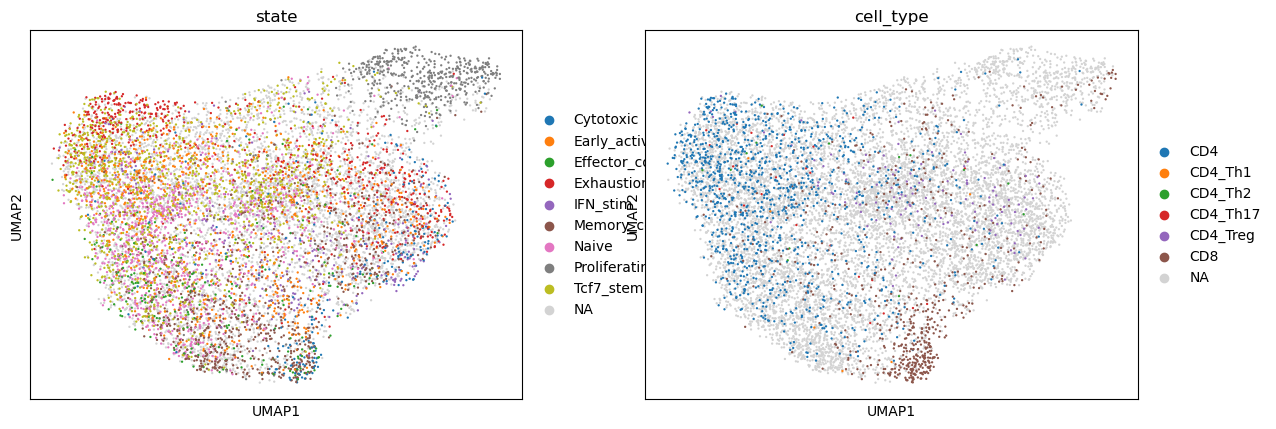

In [13]:
sc.pl.umap(mdata["gex"], color=['state', 'cell_type'])

# embed TCR AA into vector

In [14]:
min_clone = 1
cloned_mask = mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > min_clone
mdata_cloned = mdata[cloned_mask].copy()
mdata_single = mdata[~cloned_mask].copy()
mdata_cloned['airr'].obs['GSE'].value_counts()

GSE
GSE156718    3182
Name: count, dtype: int64

In [15]:
# Embed TCR AA sequences using Atchley factors and one-hot encoding
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

mdata = TCR_embedings.embed_tcr_aa(
    mdata,
    tcr_aa_obs=tcr_aa_obs,
    tcr_cat_features=tcr_cat_features,
    min_length=7, 
    max_length=22
)

Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']
Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (10557, 90)
Stored VDJ_1_cdr3_aa adjacent Atchley interactions in mdata.obsm['X_VDJ_1_cdr3_aa_atchley_pairwise'] with shape (10557, 425)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (10557, 20)

Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']
Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (9091, 90)
Stored VJ_1_cdr3_aa adjacent Atchley interactions in mdata.obsm['X_VJ_1_cdr3_aa_atchley_pairwise'] with shape (9091, 425)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (9091, 20)

VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 22 unique categories + 1 unknown = 23 dimensions
VJ_1_j_call: 41 unique categories + 1 unknown = 42 dimensions
VJ_1_v_call: 88 unique catego

In [16]:
mdata.obsm['VDJ_1_v_call']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9091, 23))

In [17]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

In [18]:
view_tcr = np.concatenate(arrs_tcr, axis=1)
print(view_tcr.shape)

# Add chain length
for chain in tcr_aa_obs:
    view_tcr = np.concatenate([view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)],  axis=1)

# Add clone size
view_tcr = np.concatenate([view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)],  axis=1)
    
print(view_tcr.shape)

(9091, 1239)
(9091, 1242)


In [19]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].X.toarray()
# view_gene = mdata['gex'].obsm['X_pca_harmony']

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)
view_gene = scaler.fit_transform(view_gene)

NameError: name 'StandardScaler' is not defined

In [ ]:
mdata.obsm['tcr_embs'] = view_tcr

## Corr

## Save

In [ ]:
importlib.reload(TCR_embedings)

<module 'functions.TCR_embedings' from '/ihome/ylee/yiz133/Code/Data processing/functions/TCR_embedings.py'>

In [ ]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
# mdata.write(f'{filename}_singlets_CVscores.h5mu')